last update : 2026.03  
제작 : 박광석 (모두의연구소)  

# 들어가며

RAG는 어느 한 곳만 잘해서는 성능이 나오지 않습니다. 검색(Retrieval)이 완벽해도 생성(Generation)에서 거짓말을 할 수 있고, 생성 능력이 뛰어나도 검색된 데이터가 쓰레기(Garbage In, Garbage Out)라면 무용지물입니다. 그렇다면 우리는 이 각각의 단계를 어떻게 '점수'로 매길 수 있을까요?  

## 기존 NLP 평가 방법의 한계

기존 NLP 평가는 평가 지표와 벤치마크를 활용하였습니다. 감성 분석이나 번역 등, 전통적인 태스크에 대해서는 어느 정도의 변별력을 보여줄 수 있었지만, LLM이 점차 커지고 많은 일들을 수행하게 되면서, 그 한계 또한 명확해졌습니다.  

**평가지표와 그 한계**

과거 기계번역이나 요약 태스크에서는 BLEU, ROUGE 같은 지표를 사용했습니다. 이들은 정답 문장(Ground Truth)과 모델이 생성한 문장 간의 **'단어 겹침(N-gram overlap)'** 을 측정합니다.  

```
정답: "애플의 2023년 총매출은 3,832억 달러입니다."  
AI 답변: "2023년 Apple의 전체 매출액은 3,832억 달러를 기록했습니다."  
```

사람이 보기엔 두 문장은 완벽히 같은 의미를 담고 있는 100점짜리 답변입니다. 하지만 BLEU나 ROUGE 지표로 평가하면 '애플' vs 'Apple', '총매출' vs '전체 매출액' 등 사용하는 단어가 다르기 때문에 매우 낮은 점수를 받게 됩니다. LLM은 본질적으로 '생성(Generation)' 모델이므로, 동일한 의미를 다른 단어와 문장 구조로 표현하는 데 능합니다. 따라서 기존의 단어 매칭 기반 평가 지표는 RAG 시스템을 평가하는 데 완전히 무용지물입니다.

**벤치마크와 그 한계**  
LLM이 더 똑똑해지고 많은 일을 수행하며, 특히 생성 태스크가 많은 가능성을 보여주며 폭발적으로 관련분야가 성장함에 따라, 답이 정해져 있지 않은 개방형 질문이나 Multi-turn 상호작용의 품질을 평가하는 것에 벤치마크 시스템의 한계가 드러났습니다.

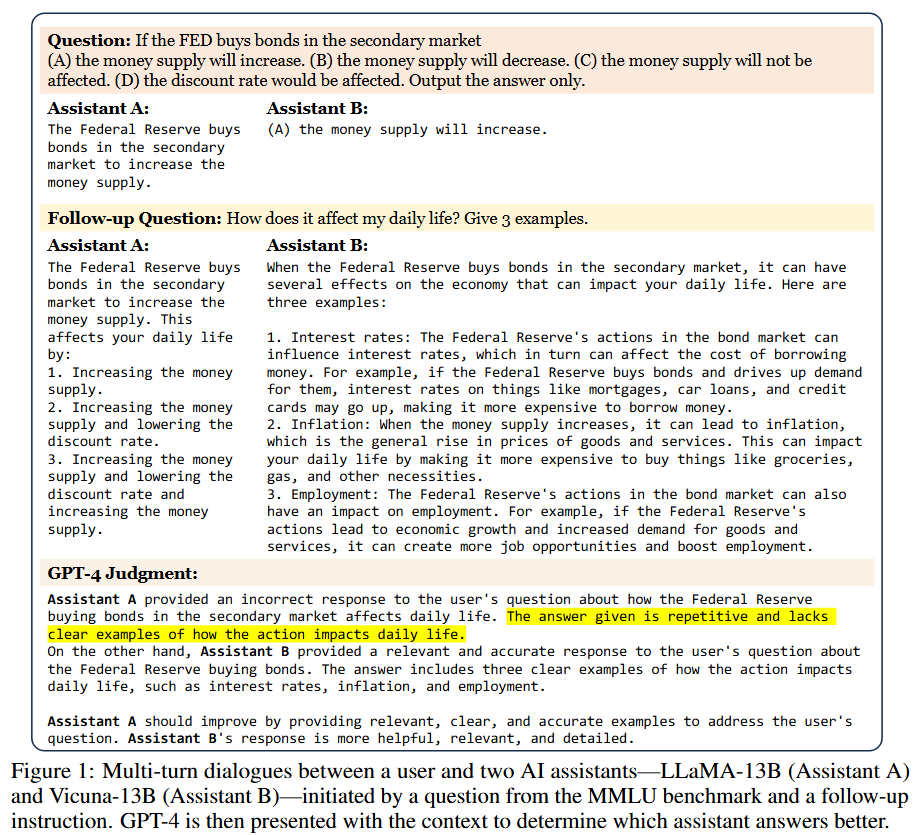

[기존 벤치마크에서 좋은 성능을 보인다고 하는 LLaMa나 Vicuna 등의 출력 결과, 확인하였을 떄, 매트릭 평가와 실제 유용성은 괴리가 있다는 것을 보여줍니다]

현재 사용되는 기존 벤치마크의 예시, 목적, 한계는 다음과 같습니다

- 핵심 지식 벤치마크 (Core-knowledge benchmarks)
  - 예시: MMLU, HellaSwag, HumanEval, GSM-8K

  - 목적: 주로 사전 학습된 LLM의 핵심적인 지식과 추론 능력을 평가합니다. 객관식 질문이나 단답형 답변을 요구하며, 자동 채점이 용이하다는 장점이 있습니다.

  - 한계: 모델의 대화 능력이나 복잡한 지시 이행 능력, 창의성 등 인간이 중요하게 여기는 질적 측면을 측정하지 못합니다.  

- 지시 이행 벤치마크 (Instruction-following benchmarks)  
  - 예시: Flan, Self-instruct, Super-NaturalInstructions

  - 목적: 지시 미세조정(Instruction fine-tuning)을 거친 모델이 얼마나 다양한 지시를 잘 따르는지 평가합니다. 핵심 지식 벤치마크보다는 더 개방적인 질문을 포함합니다.

  - 한계: 여전히 평가 기준이 제한적이며, Multi-turn 대화의 연속성이나 맥락 유지 능력을 평가하기에는 부족합니다.  

- 대화형 벤치마크 (Conversational benchmarks)
  - 예시: CoQA, OpenAssistant

  - 목적: 실제 사용 사례와 가장 유사한 대화 형식의 평가를 지향합니다.
  
  - 한계: 질문의 다양성이나 복잡성이 최신 챗봇의 발전 속도를 따라가지 못해, 모델 간의 성능 차이를 변별력 있게 구분하기 어려운 경우가 많습니다.

이러한 벤치마크들의 가장 근본적인 문제는 인간의 선호도를 직접적인 평가 척도로 삼지 않는다는 점입니다. 따라서, 인간 선호도를 직접적으로 측정하기 위한 새로운 기법이 필요합니다.  

## LLM을 평가자로 사용하자

이런 맥락에서 **"LLM을 평가자로 사용하자"** 라는 아이디어가 등장합니다. 강력한 추론 능력을 가진 LLM(예: GPT-4) 에게 평가 기준을 주고, 다른 LLM(우리가 만든 RAG)이 생성한 답변을 채점하게 만드는 것입니다.

**LLM as a judge**

LLM as a judge 방법론은 크게 세 가지의 포멧으로 활용할 수 있습니다.  

- 쌍대 비교 (Pairwise comparison)  

  Judge LLM에게 하나의 질문과 두 개의 답변을 제시하고, 어느 쪽이 더 나은지 판단하도록 합니다.  
  평가할 모델 수가 증가하면 비교해야 할 쌍의 수가 기하급수적으로 늘어나 확장성 문제가 발생할 수 있습니다.  

- 단일 답변 채점 (Single answer grading)  
  각 답변에 대해 독립적으로 점수를 할당하도록 합니다.  
  확장성이 뛰어나지만, 심사위원으로 사용하는 Judge LLM 모델이 변경될 경우 절대 점수의 기준이 달라져 점수 변동성이 커질 수 있습니다.
- 참조 기반 채점 (Reference-guided grading)  

  수학 문제와 같이 명확한 정답이 있는 경우, 사전에 생성된 참조 정답(reference solution)을 Judge LLM에게 제공하여 평가의 정확도를 높이는 방식입니다.  
  일반적인 수학이나 추론 문제를 평가할 때는 Judge LLM에게 스스로 참조 답변을 생성하라고 하지만, 난이도가 높은 수학 문제나 모델이 오답을 생성할 위험이 높을 때는 프롬프트에 참조 답변을 제공합니다.

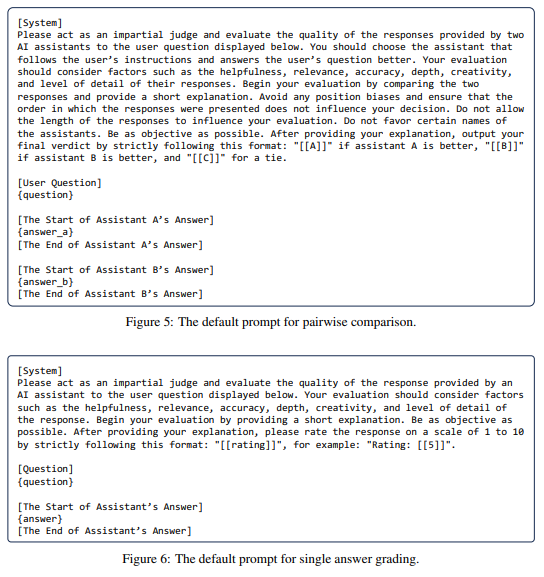

[쌍대 비교, 단일 답변 채점을 위한 프롬프트 예시]  

**G-eval**

LLM as a Judge의 발전된 형태인 G-Eval은 단순히 점수만 매기는 것이 아니라, 모델이 평가 가이드라인을 스스로 생성하고 **단계별 추론(CoT)** 을 거쳐 채점하게 하는 프롬프팅 프레임워크입니다. 이는 인간의 판단 결과와 매우 높은 상관관계(Human Correspondence)를 보이는 것으로 알려져 있습니다.

G-Eval은 채점을 위해 3단계의 논리적 절차를 가집니다.  

- 평가 지표 정의  

  평가하고자 하는 지표(예: Relevance)에 대한 정의를 프롬프트에 주입합니다.

- 평가 단계(CoT) 생성:  

  Judge LLM이 해당 지표를 공정하게 채점하기 위해 수행해야 할 세부 평가 리스트(Step-by-step instructions)를 스스로 작성하게 합니다.

- 점수 계산:  

  생성된 단계에 따라 답변을 분석하고, 마지막에 1~5점 사이의 점수를 부여합니다. 더 정밀한 결과를 위해 각 점수 토큰의 확률값을 가중 평균하여 최종 점수를 산출하기도 합니다.

G-Eval은 태스크의 성격에 맞춰, 4가지 핵심 지표를 기준으로 답변의 질을 평가합니다.

요약 Task (summeval)

- 응집도 (Coherence): 답변의 문장들이 논리적으로 연결되어 있고 흐름이 자연스러운가?

- 일관성 (Consistency): 답변 내용이 본문이나 주어진 정보와 모순되지 않고 사실 관계를 잘 유지하는가?

- 유창성 (Fluency): 문법적으로 정확하고 읽기 쉬운 문장으로 구성되어 있는가?

- 관련성 (Relevance): 사용자의 질문 의도를 정확히 파악하여 필요한 정보만을 포함하고 있는가?

생성 Task (topical-chat)

- 자연스러움 (Naturalness) : 대화 응답이 얼마나 인간과 유사한가

- 응집도 (Coherence) : 대화가 논리적으로 잘 연결되었는가

- 유도성 (Engagingness) : 대화가 사용자의 관심을 끌고 참여를 유도하는가

- 근거성 (Groundedness) : 대화가 외부 지식이나 문서에 기반하여 정확한 정보를 전달하는가

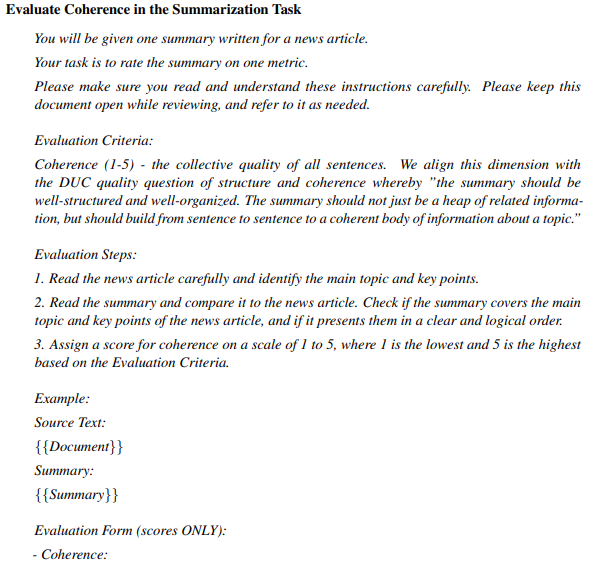

[G-eval 프롬프트 예시]

GPTScore나 NLI 가설검증 기법으로 다른 언어모델을 통한 생성물을 평가하는 방법이 소개되었었지만, LLM-as-a-judge 나 G-eval 처럼 Human alignment가 반영된 LLM에게 직접 점수나 선호도를 측정하게 하는 방법이 더 널리 쓰이고 있습니다.

**LLM-as-a-judge 의 특장점과 한계**

회사에서 상사나 고객이 이렇게 묻는다면 어떻게 대답하시겠습니까?  
- "그래서, 기존 Naive RAG보다 답변 정확도가 정확히 몇 퍼센트(%) 올랐나요?"  
- "Chunk 크기를 500에서 1000으로 늘렸을 때, 할루시네이션(환각)은 얼마나 줄었습니까?"   

이 질문에 제대로 답하기 위해서는, 통계적으로 설득가능한 수치를 확보하여 진행해야 합니다.  

한두개의 케이스로는 설명할 수 없는 전반적인 성능 비교를 위해서, 엔지니어가 직접 1,000개의 질문을 던지고 답변을 읽어보며 채점(Human Evaluation)하는 것은 시간과 비용 측면에서 불가능에 가깝기 때문입니다.  

LLM as a judge 방식으로 1,000개의 결과를 채점하는 것은 몇 분 걸리지 않습니다. 즉, 통계를 사용한 설득력 확보에 굉장히 용이합니다.

**하지만 LLM as a judge 방법이 처음에 제안되었을 때 몇가지 한계가 함께 관찰되었습니다.**

- 위치 편향 (Position Bias)

  답변이 제시되는 순서에 따라 Judge의 선호도가 달라지는 현상입니다.  
  
  실험 결과, 대부분의 Judge LLM은 먼저 제시된 답변(Assistant A)을 선호하는 경향을 보였습니다.  
  
  이 때문에, 위 쌍대 비교 예시에서는 두 응답을 비교할 시 A+B로 한번, B+A로 또 한번 비교 후, 그 중간 결과를 최종 결과로 차용하는 식으로 프롬프트를 설계하여 문제를 극복해냅니다.

- 장황함 편향 (Verbosity Bias)

  더 짧고 간결한 답변보다 내용의 질과 상관없이 더 긴 답변을 선호하는 경향을 보였습니다.
  
- 자기고양 편향 (Self-enhancement Bias)

  Judge LLM이 자기 자신 또는 동일 계열의 모델이 생성한 답변을 더 선호하는 경향을 보였습니다

이 문제들은 Multi-turn Judge, CoT 기법 적용 및 참조문서 기반 채점으로 돌파구를 찾은 상태이빈다.

## RAG 평가의 어려움

여러분들이 지금까지 공부하셨던 RAG는 여러 컴포넌트가 결합된 기법입니다. 크게 데이터 준비와 추론 및 생성으로 이루어진 두 축에서 일어나는 일을 다시 한번 짚어보며, 해당 컴포넌트에서의 작업 평가에 어떤 어려움이 예상되는지 살펴보도록 하겠습니다.

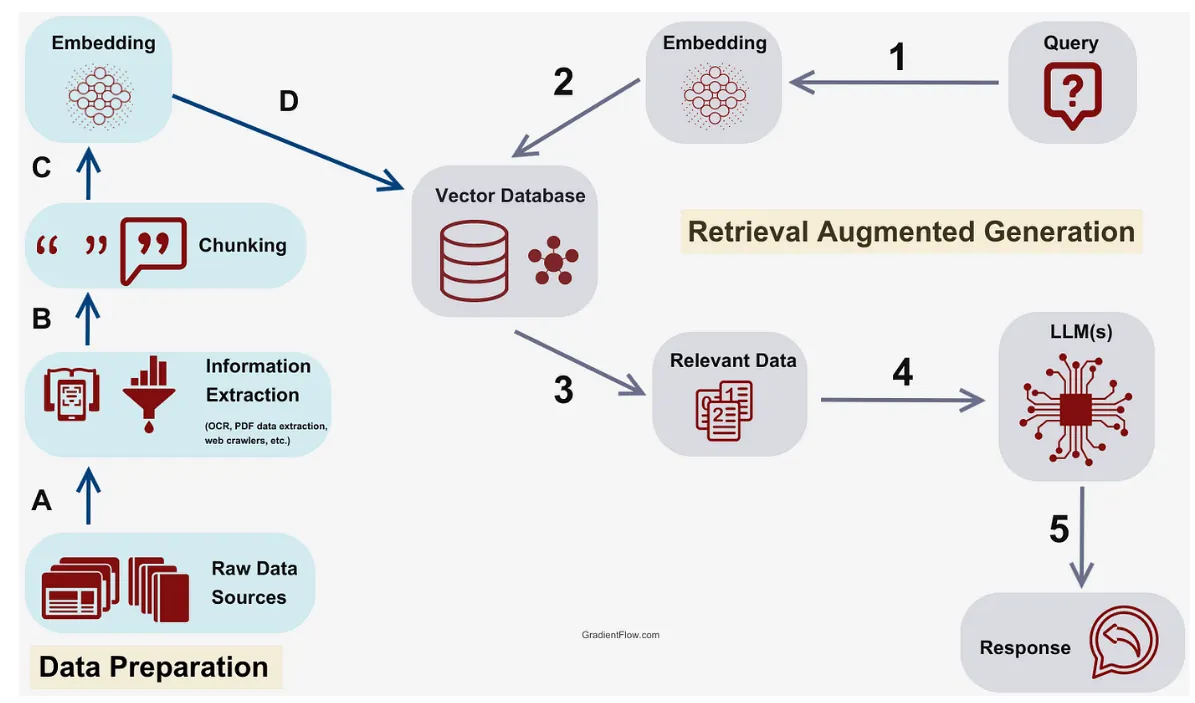

[Part 1] 데이터 준비 단계 (Data Preparation)  

A. Raw Data Sources (원천 데이터)

하는 일: PDF, 웹 크롤링, DB 등 가공되지 않은 데이터를 수집합니다.

평가의 어려움: 데이터 자체의 **'정확성'** 과 **'최신성'** 을 평가해야 합니다. 잘못된 정보가 입력되면 이후 모든 단계가 오염됩니다.

B. Information Extraction (정보 추출)

하는 일: OCR이나 파싱을 통해 텍스트를 추출합니다.

평가의 어려움: 표(Table)나 이미지 내 글자를 얼마나 정확하게 텍스트로 변환했는지 검증해야 합니다. 레이아웃이 깨지면 문맥 정보가 손실됩니다.

C. Chunking (청킹)

하는 일: 긴 문서를 검색 가능한 작은 단위(Chunk)로 자릅니다.

평가의 어려움: **'문맥 보존의 딜레마'** 입니다. 너무 작으면 의미가 단절되고, 너무 크면 검색 노이즈가 심해집니다. 최적의 청크 사이즈를 찾는 객관적 지표를 설정하기가 매우 까다롭습니다.

D. Embedding (임베딩)

하는 일: 텍스트를 숫자 벡터로 변환하여 벡터 DB에 저장합니다.

평가의 어려움: 사용자의 질문과 문서의 의미적 유사도를 얼마나 잘 매칭하는지 평가해야 합니다. 도메인 특화 용어를 모델이 이해하지 못하면 검색 품질이 급격히 떨어집니다.

[Part 2] RAG 추론 및 생성 단계 (Retrieval & Generation)  

1. Query (질문)

하는 일: 사용자가 질문을 던집니다.

평가의 어려움: 질문이 모호할 경우(Ambiguity) 시스템이 의도를 파악하기 어렵습니다.

질문의 품질을 어떻게 표준화하여 테스트 셋으로 만들지가 관건입니다.

2. Embedding (질문 임베딩)

하는 일: 질문을 문서와 비교할 수 있도록 동일한 벡터 공간으로 변환합니다.

평가의 어려움: 문서 임베딩 모델(D)과 질문 임베딩 모델 간의 정렬(Alignment)이 잘 되어 있는지 확인해야 합니다.

3. Vector Database & Retrieval (검색)

하는 일: 질문 벡터와 가장 유사한 문서 조각들을 찾아옵니다.

평가의 어려움 (핵심 지표: Context Recall): **'필요한 정보가 누락되지 않았는가?'** 를 평가합니다.

수만 개의 문서 중 정답이 포함된 문서를 상위 K개 안에 가져왔는지 정량적으로 측정해야 합니다.

4. Relevant Data (참조 문맥 전달)

하는 일: 검색된 문서들을 LLM에게 프롬프트와 함께 전달합니다.

평가의 어려움 (핵심 지표: Context Precision): **'가져온 문서들이 질문과 정말 관련이 있는가?'** 를 평가합니다.

관련 없는 문서(노이즈)가 섞여 있으면 LLM이 혼란을 느껴 잘못된 답변을 내놓을 수 있습니다.

5. LLM(s) & Response (생성 및 답변)

하는 일: 제공된 문맥을 바탕으로 최종 답변을 생성합니다.

평가의 어려움 (핵심 지표: Faithfulness & Answer Relevance):

근거성(Faithfulness): 답변이 내포된 지식이 아니라 반드시 '제공된 문서'에 기반했는지 검증합니다(할루시네이션 방지).

유용성(Relevance): 답변이 사용자의 질문에 대해 실질적인 해결책을 주는 문장인지 평가합니다.

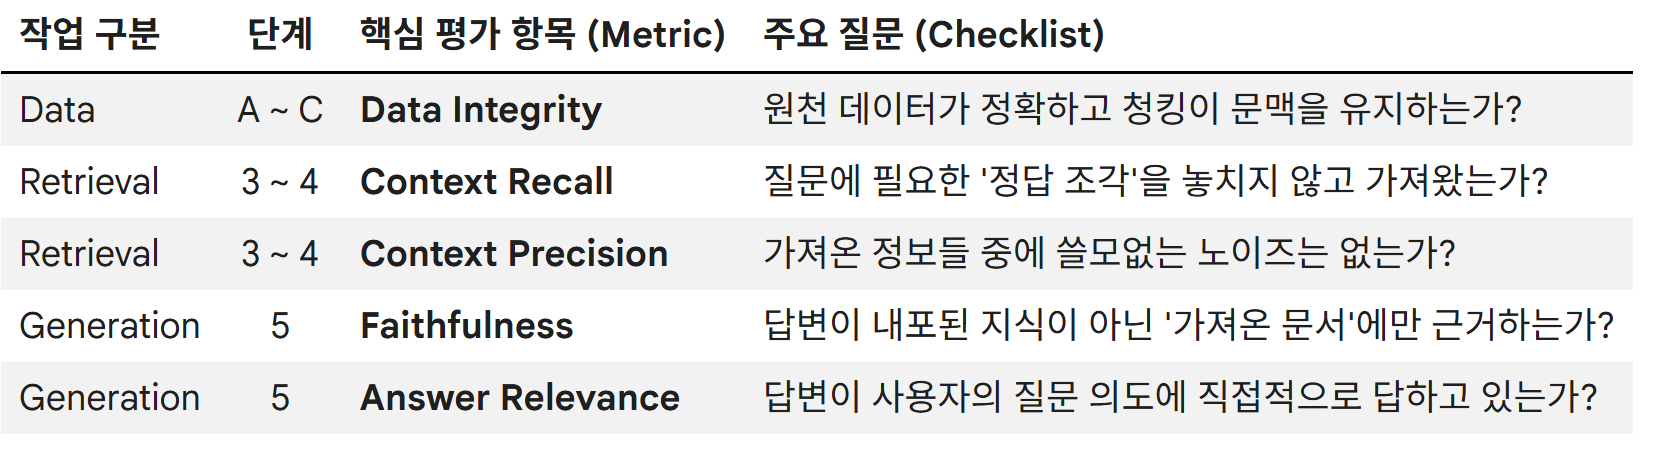

[윗 내용을 압축하자면 다음과 같습니다]

## RAGAS

 RAGAS (Retrieval Augmented Generation Assessment) 는 앞서 소개한 LLM-as-a-judge를 활용한, RAG 평가 프레임워크 입니다.

RAGAS에서는 앞서 소개한 내용을 세 가지의 축으로 수렴하여 평가합니다. 이를 **RAG Triad** 라고 부릅니다.

- Context Relevance: 질문과 검색된 문서 사이의 관련성 (3번, 4번 단계)

- Groundedness(Faithfulness): 문서와 답변 사이의 일치성 (5번 단계)

- Answer Relevance: 질문과 답변 사이의 관련성 (1번과 5번의 정렬)

이를 측정하고자 RAGAS는 RAG를 구성하는 3가지 핵심 요소 간의 관계를 확인합니다.

- Question (사용자 질문)

- Contexts (검색된 문서 조각들)

- Answer (최종 생성된 답변)

**이 세가지 요소로 상호작용을 평가하는 4가지 핵심 지표를 설정합니다.**

① Faithfulness (충실성 / 사실 부합성)  
- 생성된 답변(Answer)이 검색된 문서(Contexts)에 얼마나 충실한가? (할루시네이션 측정)  를 측정합니다  
- 관계: Contexts -> Answer
- 작동 원리 :  
  - LLM 판사(Judge)는 먼저 AI의 답변(Answer)을 여러 개의 '독립적인 주장(Statements)'으로 쪼갭니다.
  - 그 다음, 각 주장이 검색된 문서(Contexts) 내에 존재하는 정보로 뒷받침되는지 하나씩 검증합니다.
  - 점수 = (문서로 뒷받침되는 주장 수) / (전체 주장 수)
  - 예시: 검색된 문서에 "A사는 B사를 인수했다"만 있는데, 답변에 "A사는 B사를 100억에 인수했다"라고 나오면 '100억'이라는 주장은 Context에 없으므로 Faithfulness 점수가 깎입니다.  


② Answer Relevance (답변 관련성)  

- 생성된 답변(Answer)이 사용자 질문(Question)의 의도를 정확히 해결하는가? (동문서답 측정)  를 측정합니다  

- 관계: Question <-> Answer

- 작동 원리 :  
  - 이 지표는 역발상을 사용합니다. LLM 판사에게 사용자의 원래 질문을 숨기고, 오직 생성된 답변(Answer)만 보여줍니다.  
  - "이 답변이 나오려면 원래 질문이 무엇이었을까?"를 추론하여 3~4개의 '가상 질문'을 역으로 생성하게 합니다.  
  - 생성된 가상 질문들과 사용자의 실제 질문(Question) 간의 의미론적 유사도(Embedding 코사인 유사도)를 측정합니다.  
  - 이유: 답변이 질문의 핵심을 찌르고 있다면, 답변만 보고도 원래 질문을 쉽게 유추할 수 있어야 하기 때문입니다. 답변이 장황하고 핵심이 없다면 역생성된 질문이 실제 질문과 전혀 다른 방향을 가리키게 되어 점수가 낮아집니다.  

③ Context Precision (문맥 정밀도)  
- 정답이 포함된 유용한 문서가 검색 결과의 '상위(Top-k)'에 잘 랭크되어 있는가? (검색 엔진의 랭킹 품질)  를 측정합니다  

-  관계: Question <-> Contexts (Ground Truth 필요)

- 작동 원리 :  
'Re-ranking'의 효과를 증명하는 지표입니다. 사용자가 질문했을 때, 정답을 담고 있는 문서가 검색 결과 1등으로 나오는 것과 5등으로 나오는 것은 다릅니다. LLM 컨텍스트 윈도우의 'Lost in the middle(중간 정보 유실)' 현상 때문에, 중요한 정보는 무조건 상단에 위치해야 합니다. 검색된 문서 리스트를 순회하며 정답과 관련된 문서가 상위에 있을수록 더 높은 페널티 가중치를 주어 계산합니다. (추천 시스템의 MRR, NDCG 지표와 유사한 개념)

④ Context Recall (문맥 재현율)  

- 정답(Ground Truth)을 도출하는 데 필요한 모든 정보를 검색 단계에서 빠짐없이 찾아왔는가? (검색 누락 측정) 를 측정합니다

- 관계: Ground Truth -> Contexts

- 작동 원리:
  - 사람이 작성한 완벽한 정답(Ground Truth)을 여러 개의 문장(주장)으로 분리합니다.
  - 정답의 각 문장들이 검색된 문서(Contexts)에 의해 도출 가능한지 확인합니다.
  - 점수 = (Contexts에서 찾을 수 있는 정답 문장 수) / (전체 정답 문장 수)
  - 이유: 'Query Expansion'이나 'HyDE'를 적용하여 검색 범위를 넓혔을 때, 이 Context Recall 지표가 상승해야 정상입니다.

# RAGAS 사용해보기

RAGAS의 사용을 위해서는 다음과 같이 준비해주세요  

In [ ]:
# [실습 환경 준비]
# Ragas 및 LangChain 관련 최신 패키지를 설치합니다.
!pip install -qU ragas langchain langchain-openai langchain-community chromadb tiktoken nest_asyncio pandas

# RAGAS는 평가 속도를 높이기 위해 내부적으로 asyncio.gather를 사용해 수백 개의 API를 동시에 비동기 호출합니다.
# Jupyter/Colab 환경은 이미 자체적인 비동기 이벤트 루프를 돌리고 있어서 충돌이 발생합니다.
# nest_asyncio는 이 충돌을 막아주어 Colab에서도 RAGAS가 병렬 처리를 할 수 있게 해줍니다.
import nest_asyncio
nest_asyncio.apply()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.

데이터는 총 4가지를 준비합니다.  
  
- question : 사용자의 질문

- ground truth : 질문에 맞는 정답 (= 모범 답안)

- answer : LLM이 생성한 답변

- context : LLM이 답변을 생성하기 위해 참고한 정보 (=context)

허깅페이스 데이터셋을 구축하는 식으로, 데이터셋을 구축해야합니다.  
불장을 놓친 억울함을 기리며 주식 데이터로 예시를 구축해봤습니다.

In [ ]:
questions = ["주가수익비율(PER)이란 무엇이며 어떻게 계산하나요?"]
ground_truths = ["주가수익비율(PER)은 기업의 주가를 주당순이익(EPS)으로 나눈 값으로, 해당 기업의 주가가 실제 수익에 비해 얼마나 높게 형성되어 있는지를 나타내는 지표입니다. 이는 투자자들이 기업의 이익 1원을 얻기 위해 지불하는 비용을 의미하며, 보통 업종 평균 PER과 비교하여 저평가 혹은 고평가 여부를 판단합니다."]
answers = ["PER(Price Earnings Ratio)은 현재 주가를 주당순이익(EPS)으로 나눈 비율을 의미합니다. 여기서 주가는 시장에서 거래되는 가격을 말하며, 주당순이익(EPS)은 기업이 벌어들인 순이익을 발행 주식 수로 나눈 값입니다. PER이 낮을수록 해당 기업이 벌어들이는 이익에 비해 주가가 저렴하다는 '저평가' 신호로 해석될 수 있으며, 반대로 높으면 '고평가' 혹은 미래 성장성이 높다고 판단합니다."]
contexts = [[
    "A: 주가수익비율(PER)은 현재 주가를 1주당 예상 순이익(EPS)으로 나눈 수치로, 기업의 수익성 대비 주가 수준을 평가하는 핵심 지표입니다. "
    "* EPS(Earnings Per Share): 기업이 벌어들인 당기순이익을 발행주식 총수로 나눈 값. "
    "** 업종 평균 PER: 동일 산업군 내 기업들의 PER을 평균낸 값으로, 개별 기업의 상대적 가치를 판단하는 기준이 됨. "
    "\n\n"
    "| 종목명 | 현재가 | EPS | PER | 업종평균 PER | 투자판단 |"
    "| :--- | :--- | :--- | :--- | :--- | :--- |"
    "| 삼성전자 | 75,000 | 5,000 | 15.0x | 18.2x | 저평가 |"
    "| SK하이닉스 | 180,000 | 9,000 | 20.0x | 18.2x | 고평가(성장세) |"
    "| 현대차 | 250,000 | 35,000 | 7.1x | 10.5x | 저평가 |"
    "| 카카오 | 50,000 | 500 | 100.0x | 45.0x | 고평가 |"
]]

In [ ]:
from datasets import Dataset
import pandas as pd

# To dict
data = {
  "user_input": questions,
  "response": answers,
  "retrieved_contexts": contexts,
  "reference": ground_truths
}

# Convert dict to dataset
dataset = Dataset.from_dict(data)

OpenAI API key를 등록합니다.

In [ ]:
import os

In [ ]:
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_KEY')

In [ ]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
)



/tmp/ipykernel_2018/2157021597.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_2018/2157021597.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipykernel_2018/2157021597.py:2: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import (
/tmp/ipykernel_2018/2157021597.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in

다음과 같이 간단하게, 위에서 소개한 메트릭을 적용할 수 있습니다.  

In [ ]:
result = evaluate(
    dataset = dataset,
    metrics=[
        context_precision,
        context_recall,
        faithfulness,
        answer_relevancy,
    ],
)

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[3]: AttributeError('OpenAIEmbeddings' object has no attribute 'embed_query')


In [ ]:
# score 출력
print(result)
# DataFrame 생성
df = result.to_pandas()
df

{'context_precision': 1.0000, 'context_recall': 0.5000, 'faithfulness': 0.8000, 'answer_relevancy': nan}


,user_input,retrieved_contexts,response,reference,context_precision,context_recall,faithfulness,answer_relevancy
0,주가수익비율(PER)이란 무엇이며 어떻게 계산하나요?,[A: 주가수익비율(PER)은 현재 주가를 1주당 예상 순이익(EPS)으로 나눈 수...,PER(Price Earnings Ratio)은 현재 주가를 주당순이익(EPS)으로...,"주가수익비율(PER)은 기업의 주가를 주당순이익(EPS)으로 나눈 값으로, 해당 기...",1.0,0.5,0.8,NaN


LLM 세팅을 다음과 같이 커스터마이징하여 사용할 수도 있습니다.  

In [ ]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

In [ ]:
# 판사(Judge) 역할을 할 LLM과 임베딩 세팅
evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
evaluator_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [ ]:
# 평가용 가상 데이터셋
data_samples = {
    "question": [
        "프랑스의 수도는 어디이며, 가장 유명한 미술관은 무엇인가요?",
        "블랙홀의 사건의 지평선이란 무엇인가요?"
    ],
    "contexts": [
        [
            "파리는 프랑스의 수도이자 세계적인 문화 중심지입니다.",
            "루브르 박물관은 파리에 위치해 있으며, 모나리자와 같은 명작을 소장하고 있습니다."
        ],
        [
            "블랙홀은 중력이 너무 강해 빛조차 빠져나갈 수 없는 천체입니다.",
            "우주 공간에는 수많은 블랙홀이 존재한다고 추정됩니다." # 의도적 누락: 사건의 지평선 설명 없음
        ]
    ],
    "answer": [
        "프랑스의 수도는 파리이며, 가장 유명한 미술관은 루브르 박물관입니다.",
        "블랙홀의 사건의 지평선은 중력이 너무 강해 빛조차 빠져나갈 수 없는 경계면을 의미합니다. 일반 상대성 이론에 의해 예측되었습니다." # RAG 관점의 환각 발생
    ],
    "ground_truth": [
        "프랑스의 수도는 파리이고, 대표적인 미술관은 루브르 박물관입니다.",
        "사건의 지평선(Event Horizon)은 블랙홀의 탈출 속도가 빛의 속도를 넘어서는 공간의 경계입니다."
    ]
}

evaluation_dataset = Dataset.from_dict(data_samples)

In [ ]:
# 결과 평가
result = evaluate(
    dataset=evaluation_dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    raise_exceptions=False # API 에러 발생 시 중단하지 않음
)

pd.set_option('display.max_colwidth', None)
df_result = result.to_pandas()
display(df_result[['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']])

/tmp/ipykernel_2018/1109240250.py:7: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_2018/1109240250.py:7: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_2018/1109240250.py:7: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulne

RAGAS 평가를 시작합니다...


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

,faithfulness,answer_relevancy,context_precision,context_recall
0,0.500000,0.561603,0.5,1.0
1,0.666667,1.000000,1.0,0.0


데이터셋을 간단하게 구축하여, RAGAS로 간단하게 평가할 수 있는 예제를 살펴보았습니다.  
이제 여러분들이 구축하시는 RAG 에 Question-Answer 쌍을 기록하여, 개선->테스트->평가 루프를 구축할 수 있습니다.  

**그런데 Ground Truth가 없을 때는 어떻게 하나요?**

RAGAS의 핵심 지표 중 Context Recall과 Context Precision을 계산하려면 반드시 인간이 작성한 완벽한 모범 답안, 즉 **ground_truth** 가 필요합니다.  
문제는 현업에서 수백 장의 사내 매뉴얼이나 PDF를 주고 *"이 문서를 바탕으로 예상 질문 100개와 정답 100개를 만들어 오세요"*라고 하면 엄청난 노가다가 발생한다는 것입니다! 평가를 위해 몇 주 동안 정답 세트만 만들고 있을 수는 없습니다.  

이를 해결하기 위해 RAGAS는 획기적인 기능을 제공합니다.  
**바로 평가용 데이터셋 자체를 LLM이 자동으로 만들어주는 기능 (Testset Generation) 입니다.**  

우리가 가진 원본 문서들(PDF, 텍스트)을 통째로 RAGAS 모델에 던져줍니다.  
RAGAS 내부의 LLM이 문서를 쓱 읽고, "아, 일반 사용자는 이런 걸 물어보겠네?", *"이 부분은 숫자가 복잡하니 추론형 질문을 만들어야겠다"*라며 스스로 질문(Question)을 만들어냅니다.  
그리고 자신이 질문을 만든 근거가 된 문서 조각을 정답 문서(Context)로 삼고, 이상적인 답변(Ground Truth)까지 작성하여 한 세트를 완성합니다.  
단 10줄의 코드로 사람이 몇 주 걸릴 '평가용 데이터셋'을 구축할 수 있습니다.  

다음 도큐먼트를 참조하여, 프로젝트에 활용해보시기 바랍니다!  


https://docs.ragas.io/en/stable/getstarted/rag_testset_generation/

## 마치며  

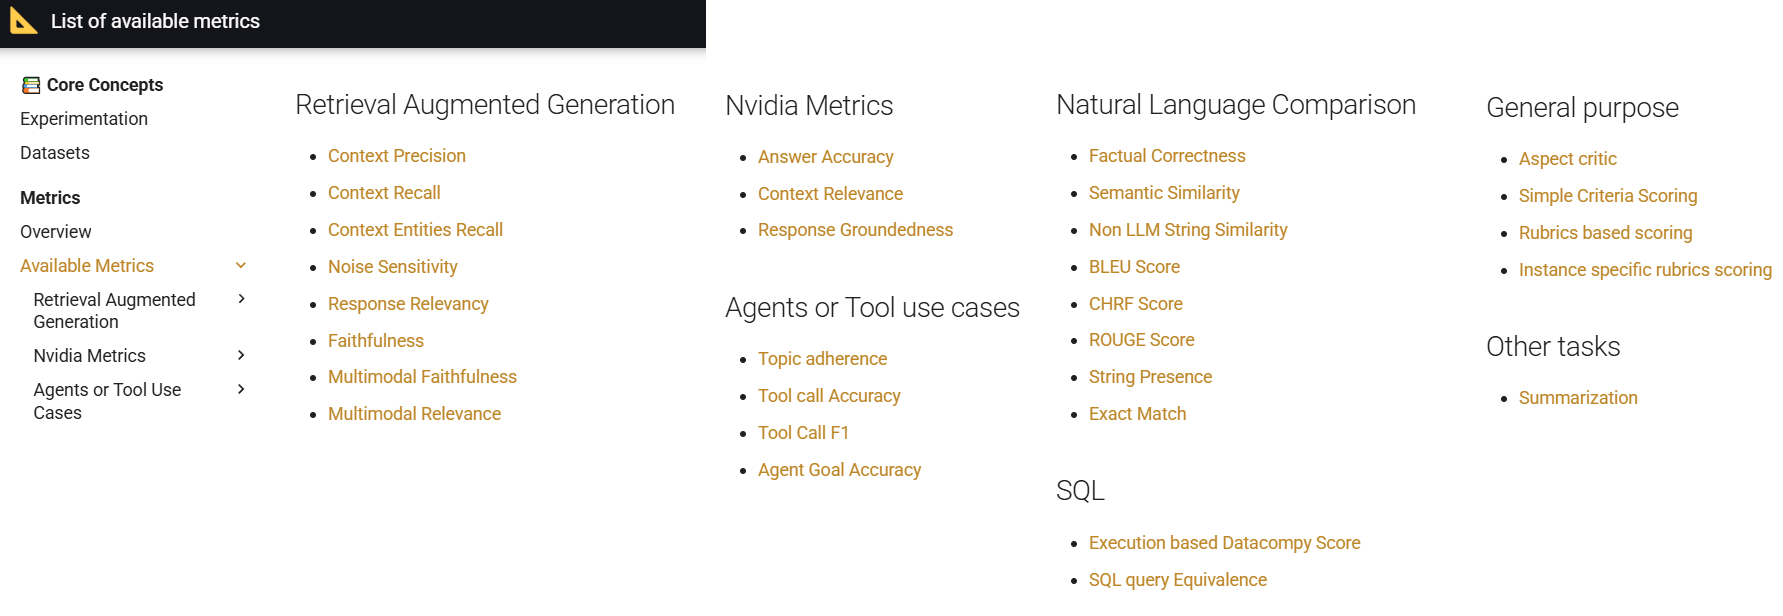

현업에서는 매트릭을 다양한 형태로 구성하고 있습니다.  
이런 요구에 맞춰, RAGAS에서는 BLEU/ROGUE 등의 전통적인 매트릭부터, Agent의 Action을 추적하는 매트릭까지 다양한 구성을 간편하게 불러올 수 있도록 지원하고 있습니다.  
https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/#other-tasks  

여러분들의 RAG도 태스크에 맞는 매트릭을 차용해, 더 견고하게 만들어보시기 바랍니다!  